# Dental Disease Classification & Multi-Model Benchmarking System
### Master Google Colab Notebook for Automated Diagnosis & Transfer Learning

**Project Overview:**
This master notebook implements an end-to-end deep learning pipeline for multi-class classification of common dental diseases using dental photography and clinical imagery.

**Target Dental Conditions (6 Classes):**
1. **Calculus**: Hardened dental plaque/tartar deposits on tooth surfaces.
2. **Caries**: Tooth decay, enamel erosion, and carious lesions/cavities.
3. **Gingivitis**: Inflammation, redness, and swelling of the gingival (gum) tissue.
4. **Tooth Discoloration**: Extrinsic/intrinsic staining, yellowing, or abnormal tooth pigmentation.
5. **Ulcers**: Oral aphthous ulcers, mucosal lesions, or canker sores.
6. **Hypodontia**: Congenital absence of one or more teeth.

**Pipeline Features:**
- **Automated Google Drive Integration**: Mounts `/content/drive` and extracts `DATASET.zip`.
- **Automated Directory Traversal**: Resolves class subdirectories despite nested archive variations.
- **Exploratory Data Analysis (EDA)**: Split statistics, stacked class distribution bar charts, and sample image grids.
- **Data Augmentation & Preprocessing**: PyTorch data transforms with normalization for transfer learning.
- **3-Model Transfer Learning Benchmarking**:
  1. **ResNet-18** (Residual network architecture baseline)
  2. **EfficientNet-B0** (Compound scaling architecture optimizing accuracy and parameter count)
  3. **MobileNetV3-Large** (Efficient mobile-optimized architecture with Squeeze-and-Excitation)
- **Comprehensive Evaluation**: Loss/Accuracy training curves, side-by-side Confusion Matrices, Classification Reports, and Performance Leaderboards.
- **Explainable AI (Grad-CAM)**: Visual attention heatmaps displaying diagnostic regions of interest.
- **Model Export**: Saving state dictionaries for downstream clinical deployment.

In [ ]:
# Import core libraries
import os
import sys
import glob
import shutil
import random
import time
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Scikit-learn metrics & utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

# PyTorch & Torchvision
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision.models import (
    resnet18, ResNet18_Weights,
    efficientnet_b0, EfficientNet_B0_Weights,
    mobilenet_v3_large, MobileNet_V3_Large_Weights
)

# Set random seed for reproducibility across all runs
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Set compute device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using compute device: {device}")
if torch.cuda.is_available():
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")

Using compute device: cuda
GPU Model: Tesla T4


## Step 1: Google Drive Mounting & Automated Dataset Extraction
This step mounts your Google Drive and searches for `DATASET.zip` in `/content/drive/MyDrive/` (or current workspace `/content/`).
It automatically unzips the dataset into `/content/raw_dataset`.

In [ ]:
# Mount Google Drive (if running in Google Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    in_colab = True
    print("Google Drive mounted successfully.")
except ImportError:
    in_colab = False
    print("Running in local environment (not Google Colab).")

# Locate DATASET.zip
possible_zip_paths = [
    '/content/drive/MyDrive/DATASET.zip',
    '/content/drive/MyDrive/Dental/DATASET.zip',
    '/content/drive/MyDrive/Dental Care/DATASET.zip',
    '/content/DATASET.zip',
    './DATASET.zip',
    'DATASET.zip'
]

zip_file_path = None
for p in possible_zip_paths:
    if os.path.exists(p):
        zip_file_path = p
        break

if zip_file_path is None:
    raise FileNotFoundError(
        "DATASET.zip not found! Please place DATASET.zip in your Google Drive 'MyDrive' folder "
        "or upload it to Colab environment root (/content/DATASET.zip)."
    )

print(f"Found dataset archive at: {zip_file_path}")

# Extract zip file
raw_dataset_dir = '/content/raw_dataset' if in_colab else './scratch/test_extract'
os.makedirs(raw_dataset_dir, exist_ok=True)

print(f"Extracting dataset to '{raw_dataset_dir}'...")
start_time = time.time()
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(raw_dataset_dir)
print(f"Extraction completed in {time.time() - start_time:.2f} seconds!")

Mounted at /content/drive
Google Drive mounted successfully.
Found dataset archive at: /content/drive/MyDrive/DATASET.zip
Extracting dataset to '/content/raw_dataset'...
Extraction completed in 8.99 seconds!


## Step 2: Dataset Organization & Stratified Train/Val/Test Split
Traverses the extracted directory to collect images for each of the 6 target dental conditions:
- **Calculus**
- **Caries**
- **Gingivitis**
- **Tooth Discoloration**
- **Ulcers**
- **Hypodontia**

Organizes them into a clean PyTorch-compatible directory structure:
- `dataset/train/` (72%)
- `dataset/val/` (18%)
- `dataset/test/` (10%)

In [ ]:
# Target disease categories
target_classes = ['Calculus', 'Caries', 'Gingivitis', 'Tooth Discoloration', 'Ulcers', 'Hypodontia']

# Base directory for organized PyTorch split dataset
base_dir = '/content/dataset' if in_colab else './dataset_split'

# Create output folders
splits = ['train', 'val', 'test']
for s in splits:
    for cls in target_classes:
        os.makedirs(os.path.join(base_dir, s, cls), exist_ok=True)

# Find image files per class using robust matching
found_images = {cls: [] for cls in target_classes}

for root, dirs, files in os.walk(raw_dataset_dir):
    imgs = [os.path.join(root, f) for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    if not imgs:
        continue

    root_clean = root.replace('\\', '/').replace('\\', '/').lower()

    if 'calculus/calculus' in root_clean or (root_clean.endswith('/calculus') and not 'yolo' in root_clean):
        found_images['Calculus'].extend(imgs)
    elif 'caries augmented data set/preview' in root_clean or ('caries' in root_clean and 'preview' in root_clean):
        found_images['Caries'].extend(imgs)
    elif 'gingivitis/gingivitis' in root_clean or (root_clean.endswith('/gingivitis') and not 'yolo' in root_clean):
        found_images['Gingivitis'].extend(imgs)
    elif 'mouth_ulcer_augmented_dataset/preview' in root_clean or ('ulcer' in root_clean and 'preview' in root_clean):
        found_images['Ulcers'].extend(imgs)
    elif 'tooth_discoloration_augmented_dataser/preview' in root_clean or ('discoloration' in root_clean and 'preview' in root_clean):
        found_images['Tooth Discoloration'].extend(imgs)
    elif 'hypodontia/hypodontia' in root_clean or root_clean.endswith('/hypodontia'):
        found_images['Hypodontia'].extend(imgs)

# Fallback check if any class is missing or empty
for cls in target_classes:
    if len(found_images[cls]) == 0:
        print(f"Warning: Primary pattern missed {cls}. Performing fallback search...")
        for root, dirs, files in os.walk(raw_dataset_dir):
            imgs = [os.path.join(root, f) for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
            if not imgs:
                continue
            root_clean = root.replace('\\', '/').lower()
            cls_key = cls.lower().replace(' ', '')
            if cls_key in root_clean.replace(' ', ''):
                found_images[cls].extend(imgs)
        # Deduplicate
        found_images[cls] = list(set(found_images[cls]))

print("\n--- Summary of Found Images per Class ---")
for cls, img_list in found_images.items():
    print(f"Class '{cls:19s}': {len(img_list):5d} images")

# Copy & split images (72% Train, 18% Val, 10% Test)
class_split_counts = {cls: {'train': 0, 'val': 0, 'test': 0} for cls in target_classes}

for cls_name, image_paths in found_images.items():
    if not image_paths:
        continue

    # 90% train+val, 10% test
    train_val_paths, test_paths = train_test_split(image_paths, test_size=0.10, random_state=42)
    # 80% train, 20% val of remaining 90% -> 72% train, 18% val total
    train_paths, val_paths = train_test_split(train_val_paths, test_size=0.20, random_state=42)

    split_map = {'train': train_paths, 'val': val_paths, 'test': test_paths}

    for split_name, paths in split_map.items():
        class_split_counts[cls_name][split_name] = len(paths)
        for img_path in paths:
            target_path = os.path.join(base_dir, split_name, cls_name, os.path.basename(img_path))
            shutil.copy(img_path, target_path)

print("\nDataset successfully organized into Train (72%), Val (18%), Test (10%) splits!")


--- Summary of Found Images per Class ---
Class 'Calculus           ':  1296 images
Class 'Caries             ':  2382 images
Class 'Gingivitis         ':  2349 images
Class 'Tooth Discoloration':  1834 images
Class 'Ulcers             ':  2541 images
Class 'Hypodontia         ':  1251 images

Dataset successfully organized into Train (72%), Val (18%), Test (10%) splits!


## Step 3: Exploratory Data Analysis (EDA)
Inspect class distributions, summary statistics, and visualize sample images from each dental condition.

--- Class Distribution Table ---


,train,val,test,Total
Calculus,932,234,130,1296
Caries,1714,429,239,2382
Gingivitis,1691,423,235,2349
Tooth Discoloration,1320,330,184,1834
Ulcers,1828,458,255,2541
Hypodontia,900,225,126,1251


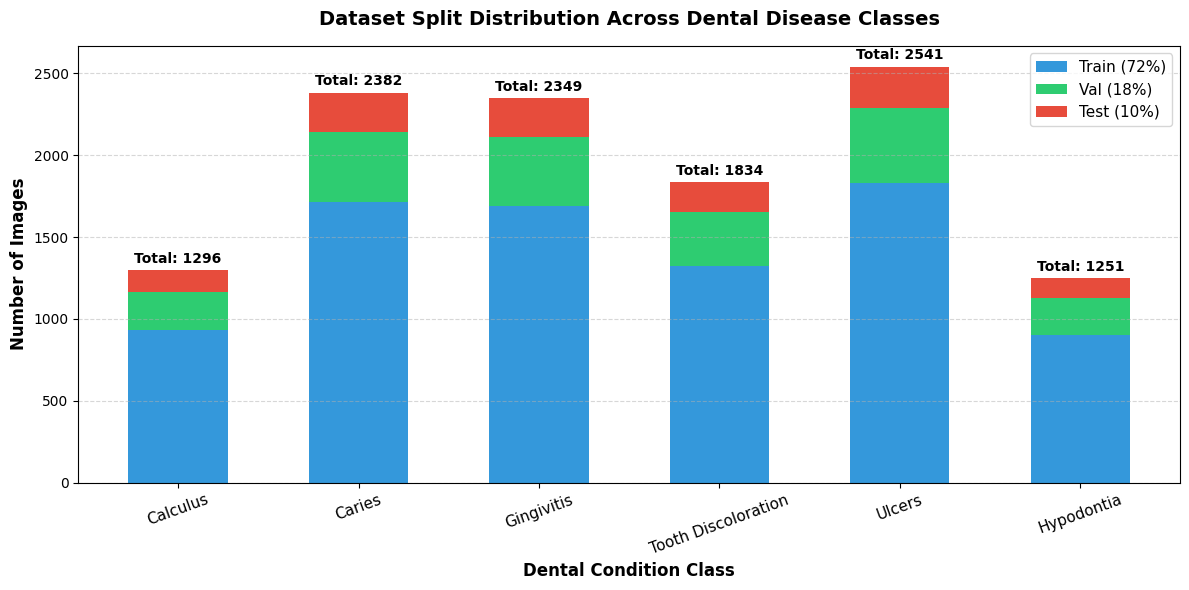

In [ ]:
# Create EDA Summary DataFrame
df_split = pd.DataFrame(class_split_counts).T
df_split['Total'] = df_split['train'] + df_split['val'] + df_split['test']
print("--- Class Distribution Table ---")
display(df_split)

# Stacked Bar Plot
plt.figure(figsize=(12, 6))
x = np.arange(len(target_classes))
width = 0.55

p1 = plt.bar(x, df_split['train'], width, label='Train (72%)', color='#3498db')
p2 = plt.bar(x, df_split['val'], width, bottom=df_split['train'], label='Val (18%)', color='#2ecc71')
p3 = plt.bar(x, df_split['test'], width, bottom=df_split['train']+df_split['val'], label='Test (10%)', color='#e74c3c')

plt.xlabel('Dental Condition Class', fontsize=12, fontweight='bold')
plt.ylabel('Number of Images', fontsize=12, fontweight='bold')
plt.title('Dataset Split Distribution Across Dental Disease Classes', fontsize=14, fontweight='bold', pad=15)
plt.xticks(x, target_classes, rotation=20, fontsize=11)
plt.legend(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add counts on top of bars
for i in range(len(target_classes)):
    tot = df_split['Total'].iloc[i]
    plt.text(i, tot + max(df_split['Total'])*0.01, f"Total: {tot}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

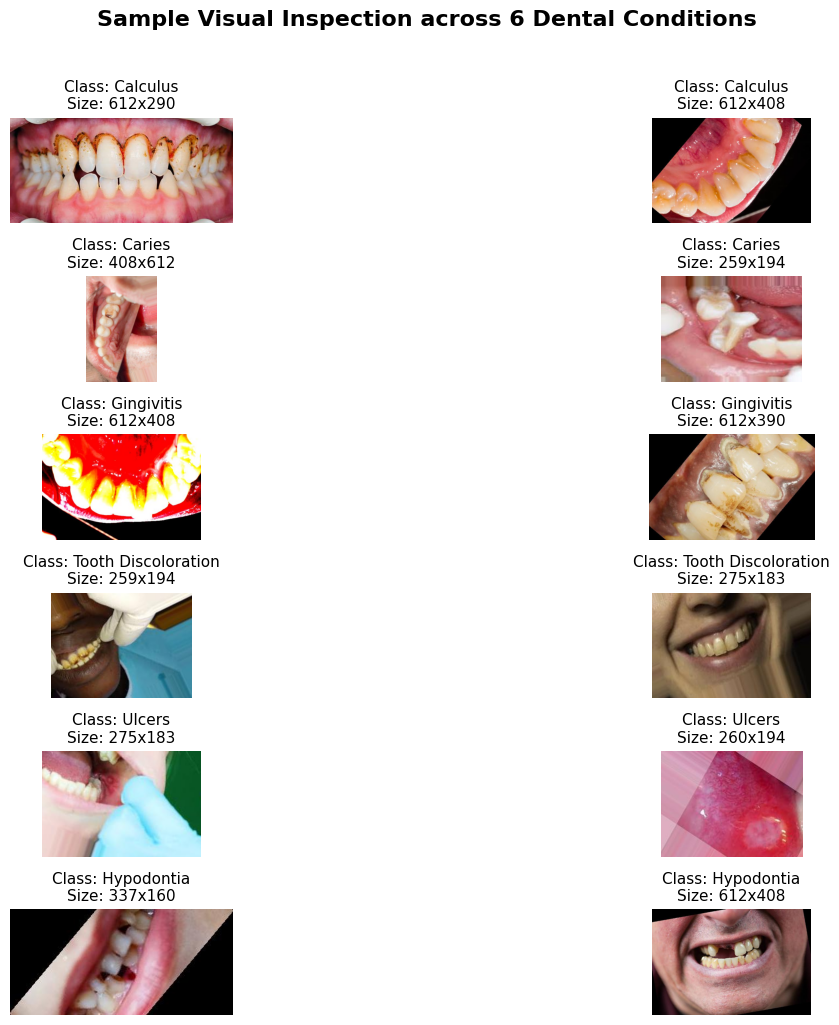

In [ ]:
# Visualize random sample images per class
num_samples_per_class = 2
plt.figure(figsize=(16, 10))
fig_idx = 1

for cls in target_classes:
    cls_dir = os.path.join(base_dir, 'train', cls)
    all_imgs = [os.path.join(cls_dir, f) for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sample_imgs = random.sample(all_imgs, min(num_samples_per_class, len(all_imgs)))

    for img_p in sample_imgs:
        img = Image.open(img_p).convert('RGB')
        ax = plt.subplot(len(target_classes), num_samples_per_class, fig_idx)
        ax.imshow(img)
        ax.set_title(f"Class: {cls}\nSize: {img.size[0]}x{img.size[1]}", fontsize=11)
        ax.axis('off')
        fig_idx += 1

plt.suptitle("Sample Visual Inspection across 6 Dental Conditions", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Step 4: Data Augmentation & PyTorch DataLoaders
Define image augmentation pipelines (cropping, flipping, rotation, color jittering, normalization) and construct DataLoader instances.

In [ ]:
image_size = (224, 224)
batch_size = 32

# Training data augmentation
train_transforms = transforms.Compose([
    transforms.Resize((240, 240)),
    transforms.RandomResizedCrop(image_size, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Validation & Testing data transforms
eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Load PyTorch Datasets
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

train_dataset = ImageFolder(train_dir, transform=train_transforms)
val_dataset = ImageFolder(val_dir, transform=eval_transforms)
test_dataset = ImageFolder(test_dir, transform=eval_transforms)

class_names = train_dataset.classes
num_classes = len(class_names)

print(f"Classes resolved by ImageFolder ({num_classes}): {class_names}")

num_workers = 2 if torch.cuda.is_available() else 0

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

print(f"DataLoaders prepared: Train ({len(train_dataset)} samples), Val ({len(val_dataset)} samples), Test ({len(test_dataset)} samples)")

Classes resolved by ImageFolder (6): ['Calculus', 'Caries', 'Gingivitis', 'Hypodontia', 'Tooth Discoloration', 'Ulcers']
DataLoaders prepared: Train (8385 samples), Val (2099 samples), Test (1169 samples)


## Step 5: Model Architectures & Transfer Learning Strategy
We initialize **3 distinct pre-trained CNN architectures**:
1. **ResNet-18**: Residual learning baseline with 11.2M parameters.
2. **EfficientNet-B0**: Compound scaled CNN optimizing FLOPs and parameter efficiency (~4.0M parameters).
3. **MobileNetV3-Large**: Highly efficient mobile architecture with hard-swish activations and Squeeze-and-Excitation (~4.2M parameters).

Each model's final classification layer is replaced with a custom Linear classifier for our 6 dental classes.

In [ ]:
def build_model(model_name, num_classes):
    """
    Factory function to initialize pre-trained models with custom classifier heads.
    """
    if model_name == 'ResNet18':
        weights = ResNet18_Weights.DEFAULT
        model = resnet18(weights=weights)
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, num_classes)
        )
    elif model_name == 'EfficientNet-B0':
        weights = EfficientNet_B0_Weights.DEFAULT
        model = efficientnet_b0(weights=weights)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, num_classes)
        )
    elif model_name == 'MobileNetV3-Large':
        weights = MobileNet_V3_Large_Weights.DEFAULT
        model = mobilenet_v3_large(weights=weights)
        in_features = model.classifier[3].in_features
        model.classifier[3] = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, num_classes)
        )
    else:
        raise ValueError(f"Unsupported model_name: {model_name}")

    return model

# Test model initialization
for m_name in ['ResNet18', 'EfficientNet-B0', 'MobileNetV3-Large']:
    m = build_model(m_name, num_classes)
    total_params = sum(p.numel() for p in m.parameters())
    trainable_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"Model '{m_name:18s}' initialized | Total Params: {total_params:,} | Trainable: {trainable_params:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 165MB/s]


Model 'ResNet18          ' initialized | Total Params: 11,179,590 | Trainable: 11,179,590
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 140MB/s]


Model 'EfficientNet-B0   ' initialized | Total Params: 4,015,234 | Trainable: 4,015,234
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 153MB/s]

Model 'MobileNetV3-Large ' initialized | Total Params: 4,209,718 | Trainable: 4,209,718


## Step 6: Unified Training Pipeline with Early Stopping
Defines a robust training and validation loop supporting Early Stopping, LR Scheduler (`ReduceLROnPlateau`), metrics history logging, and checkpoint saving.

In [ ]:
class EarlyStopping:
    """Early stops the training if validation loss doesn't improve after a given patience."""
    def __init__(self, patience=4, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

def train_model(model_name, model, train_loader, val_loader, num_epochs=15, lr=0.0003, device=device):
    print(f"\n==================================================")
    print(f"   STARTING TRAINING: {model_name}")
    print(f"==================================================")

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    early_stopping = EarlyStopping(patience=4)

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'learning_rate': [],
        'training_time_sec': 0.0
    }

    best_val_loss = float('inf')
    best_model_weights = None
    start_time = time.time()

    for epoch in range(num_epochs):
        # Training Phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = correct / total

        # Validation Phase
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (preds == labels).sum().item()

        epoch_val_loss = val_running_loss / len(val_loader.dataset)
        epoch_val_acc = val_correct / val_total

        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step(epoch_val_loss)

        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)
        history['learning_rate'].append(current_lr)

        print(f"Epoch [{epoch+1:02d}/{num_epochs:02d}] | "
              f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f} | LR: {current_lr:.6f}")

        # Save best weights
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_weights = model.state_dict().copy()

        # Check early stopping
        early_stopping(epoch_val_loss)
        if early_stopping.early_stop:
            print(f"Early stopping triggered at epoch {epoch+1}!")
            break

    total_time = time.time() - start_time
    history['training_time_sec'] = total_time
    print(f"Completed training '{model_name}' in {total_time/60:.2f} minutes.")

    # Load best weights
    model.load_state_dict(best_model_weights)

    # Save model checkpoint to disk
    save_path = f"{model_name.lower().replace('-', '_')}_dental.pth"
    torch.save({
        'model_name': model_name,
        'state_dict': model.state_dict(),
        'class_names': class_names,
        'best_val_loss': best_val_loss
    }, save_path)
    print(f"Saved best model checkpoint to '{save_path}'")

    return model, history

## Step 7: Training & Benchmarking 3 Deep Learning Models
Sequentially train ResNet-18, EfficientNet-B0, and MobileNetV3-Large.

In [ ]:
trained_models = {}
histories = {}
num_epochs = 15  # Set to 15 epochs with Early Stopping for optimal convergence

models_to_train = ['ResNet18', 'EfficientNet-B0', 'MobileNetV3-Large']

for m_name in models_to_train:
    set_seed(42)  # Reset seed for identical training conditions
    m_instance = build_model(m_name, num_classes)
    trained_m, hist = train_model(
        model_name=m_name,
        model=m_instance,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=num_epochs,
        lr=0.0003,
        device=device
    )
    trained_models[m_name] = trained_m
    histories[m_name] = hist


   STARTING TRAINING: ResNet18
Epoch [01/15] | Train Loss: 0.5396 | Train Acc: 0.7853 | Val Loss: 0.3932 | Val Acc: 0.8394 | LR: 0.000300
Epoch [02/15] | Train Loss: 0.3201 | Train Acc: 0.8723 | Val Loss: 0.3202 | Val Acc: 0.8685 | LR: 0.000300
Epoch [03/15] | Train Loss: 0.2577 | Train Acc: 0.8900 | Val Loss: 0.2044 | Val Acc: 0.9081 | LR: 0.000300
Epoch [04/15] | Train Loss: 0.2344 | Train Acc: 0.9027 | Val Loss: 0.2756 | Val Acc: 0.8947 | LR: 0.000300
Epoch [05/15] | Train Loss: 0.2091 | Train Acc: 0.9122 | Val Loss: 0.2315 | Val Acc: 0.8957 | LR: 0.000300
Epoch [06/15] | Train Loss: 0.2155 | Train Acc: 0.9096 | Val Loss: 0.2383 | Val Acc: 0.9042 | LR: 0.000300
Epoch [07/15] | Train Loss: 0.1509 | Train Acc: 0.9321 | Val Loss: 0.1501 | Val Acc: 0.9343 | LR: 0.000150
Epoch [08/15] | Train Loss: 0.1286 | Train Acc: 0.9410 | Val Loss: 0.1526 | Val Acc: 0.9271 | LR: 0.000150
Epoch [09/15] | Train Loss: 0.1204 | Train Acc: 0.9407 | Val Loss: 0.1887 | Val Acc: 0.9190 | LR: 0.000150
Epoch

## Step 8: Multi-Model Evaluation & Benchmarking
We perform comprehensive evaluation on the independent **Test Dataset** (10% split) for all 3 models:
- **Loss & Accuracy Learning Curves**
- **Test Metric Calculations** (Accuracy, Precision, Recall, Macro F1, Weighted F1)
- **Side-by-Side Confusion Matrices**
- **Classification Reports**
- **Comparative Metrics Chart & Leaderboard Table**

In [ ]:
def evaluate_model_on_test(model, test_loader, device=device):
    model.eval()
    y_true = []
    y_pred = []
    y_probs = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_probs = np.array(y_probs)

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    macro_prec, macro_rec, macro_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')

    return {
        'y_true': y_true,
        'y_pred': y_pred,
        'y_probs': y_probs,
        'accuracy': acc,
        'weighted_precision': prec,
        'weighted_recall': rec,
        'weighted_f1': f1,
        'macro_precision': macro_prec,
        'macro_recall': macro_rec,
        'macro_f1': macro_f1
    }

test_results = {}
for m_name, m_inst in trained_models.items():
    test_results[m_name] = evaluate_model_on_test(m_inst, test_loader)
    print(f"Model '{m_name:18s}' | Test Acc: {test_results[m_name]['accuracy']:.4f} | Weighted F1: {test_results[m_name]['weighted_f1']:.4f}")

Model 'ResNet18          ' | Test Acc: 0.9410 | Weighted F1: 0.9408
Model 'EfficientNet-B0   ' | Test Acc: 0.9444 | Weighted F1: 0.9450
Model 'MobileNetV3-Large ' | Test Acc: 0.9418 | Weighted F1: 0.9416


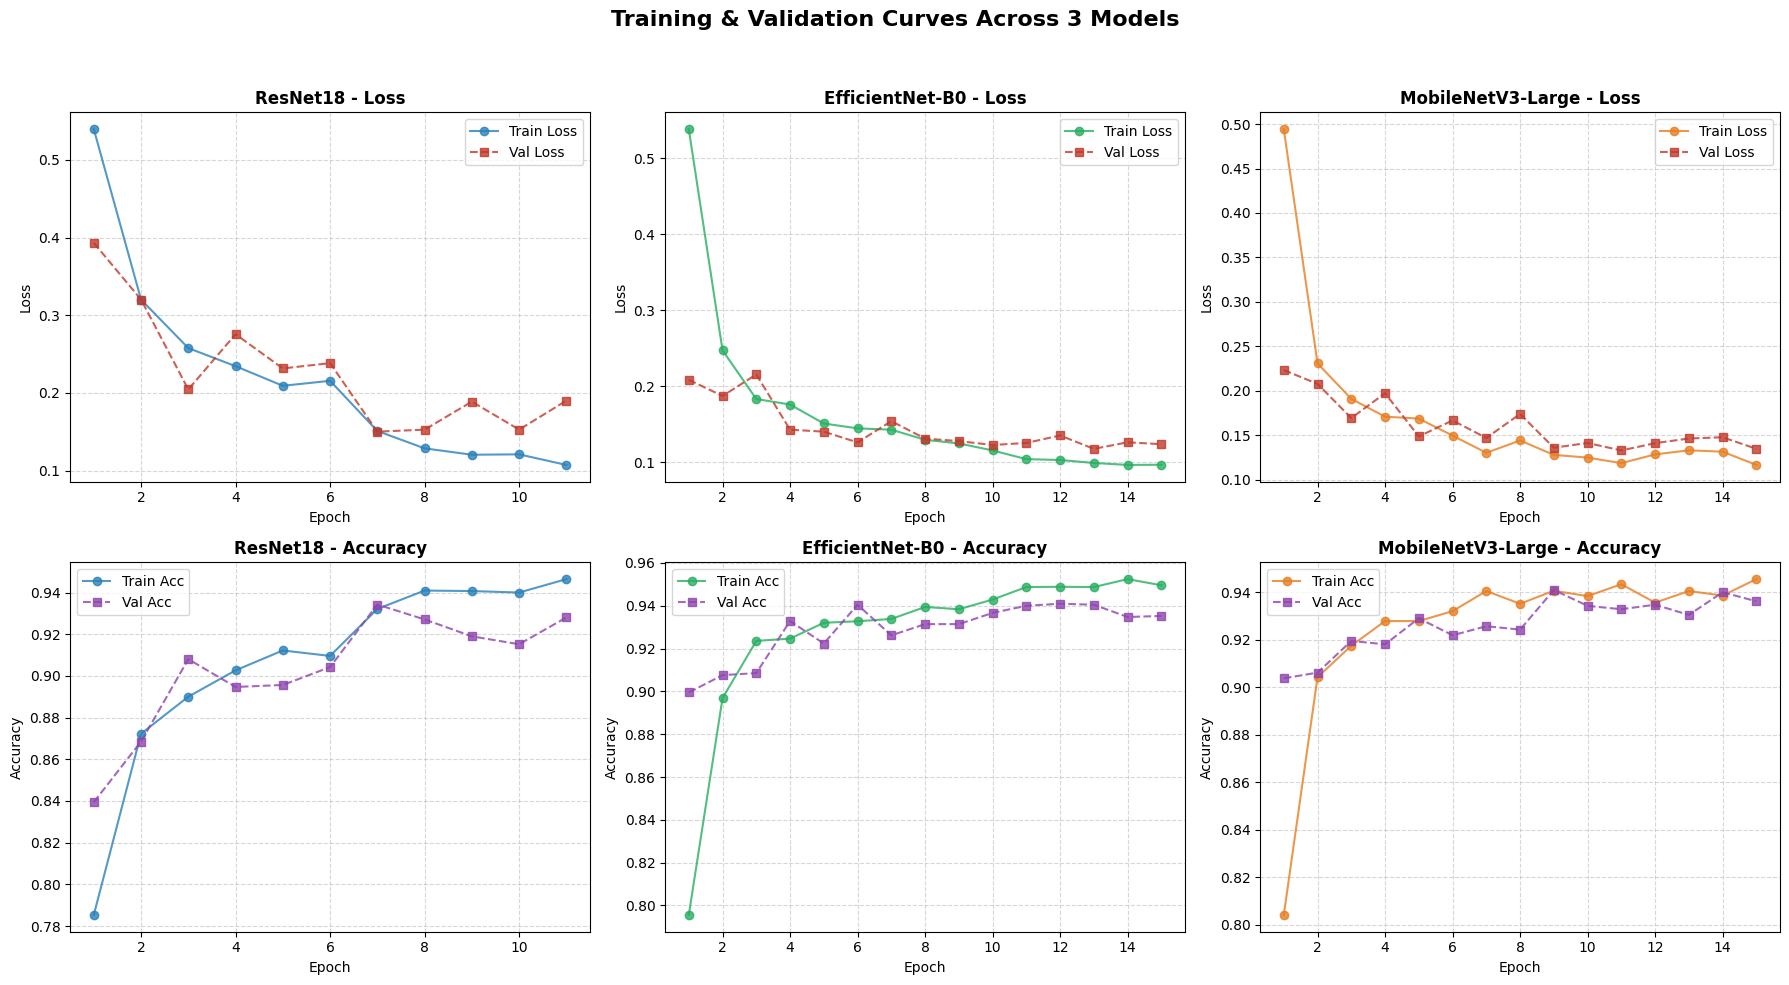

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Training & Validation Curves Across 3 Models", fontsize=16, fontweight='bold', y=0.98)

colors = {'ResNet18': '#2980b9', 'EfficientNet-B0': '#27ae60', 'MobileNetV3-Large': '#e67e22'}

for i, (m_name, hist) in enumerate(histories.items()):
    epochs = range(1, len(hist['train_loss']) + 1)

    # Loss plot
    ax_loss = axes[0, i]
    ax_loss.plot(epochs, hist['train_loss'], 'o-', label='Train Loss', color=colors[m_name], alpha=0.8)
    ax_loss.plot(epochs, hist['val_loss'], 's--', label='Val Loss', color='#c0392b', alpha=0.8)
    ax_loss.set_title(f"{m_name} - Loss", fontsize=12, fontweight='bold')
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.legend()
    ax_loss.grid(True, linestyle='--', alpha=0.5)

    # Accuracy plot
    ax_acc = axes[1, i]
    ax_acc.plot(epochs, hist['train_acc'], 'o-', label='Train Acc', color=colors[m_name], alpha=0.8)
    ax_acc.plot(epochs, hist['val_acc'], 's--', label='Val Acc', color='#8e44ad', alpha=0.8)
    ax_acc.set_title(f"{m_name} - Accuracy", fontsize=12, fontweight='bold')
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.legend()
    ax_acc.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

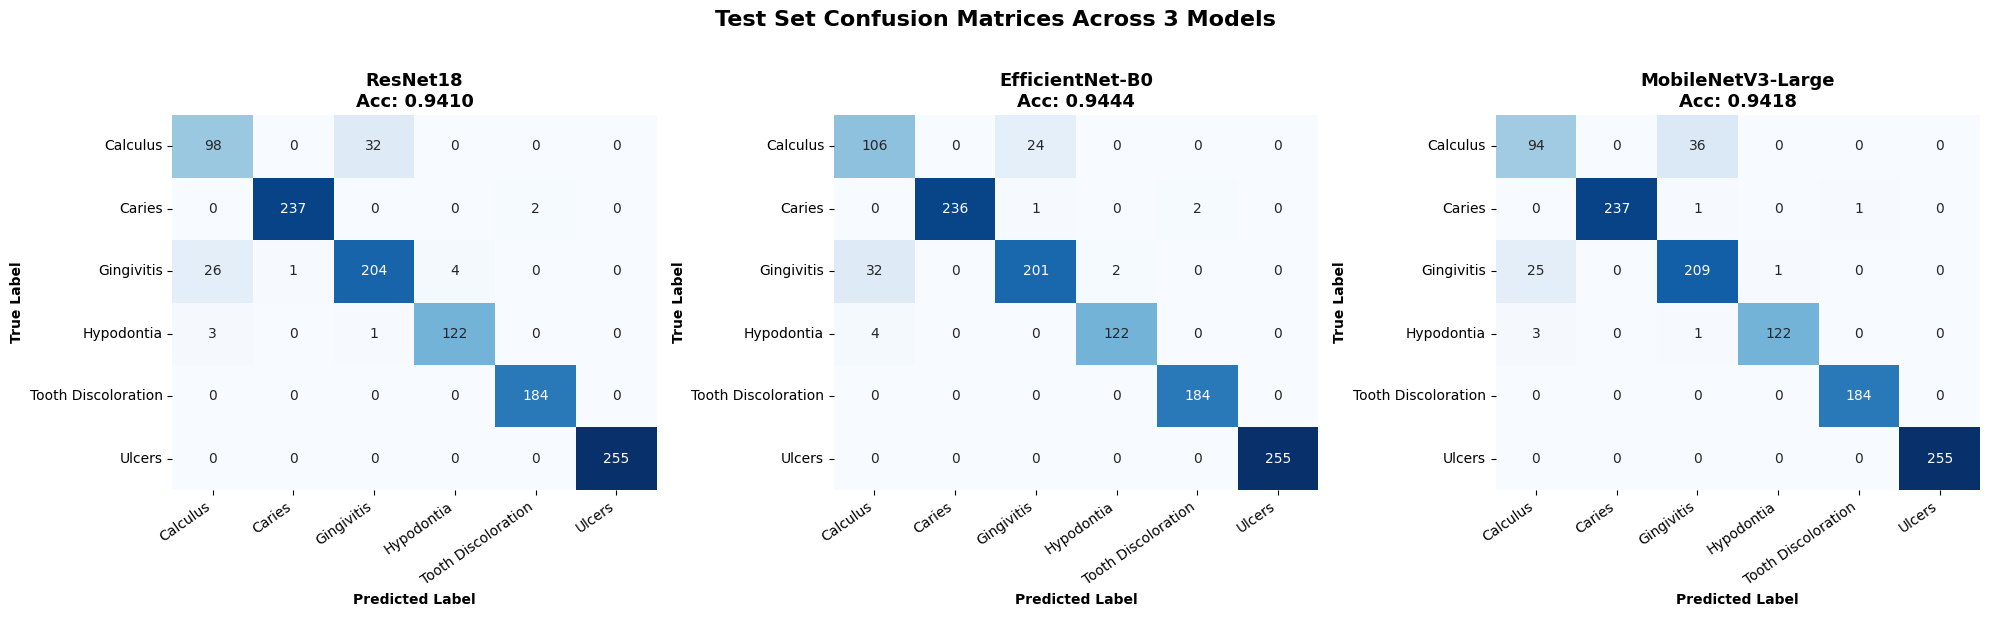

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Test Set Confusion Matrices Across 3 Models", fontsize=16, fontweight='bold', y=1.02)

for i, (m_name, res) in enumerate(test_results.items()):
    cm = confusion_matrix(res['y_true'], res['y_pred'])
    ax = axes[i]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f"{m_name}\nAcc: {res['accuracy']:.4f}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Predicted Label", fontweight='bold')
    ax.set_ylabel("True Label", fontweight='bold')
    ax.set_xticklabels(class_names, rotation=35, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
for m_name, res in test_results.items():
    print(f"\n==================================================")
    print(f"   CLASSIFICATION REPORT: {m_name}")
    print(f"==================================================")
    rep = classification_report(res['y_true'], res['y_pred'], target_names=class_names, digits=4)
    print(rep)


   CLASSIFICATION REPORT: ResNet18
                     precision    recall  f1-score   support

           Calculus     0.7717    0.7538    0.7626       130
             Caries     0.9958    0.9916    0.9937       239
         Gingivitis     0.8608    0.8681    0.8644       235
         Hypodontia     0.9683    0.9683    0.9683       126
Tooth Discoloration     0.9892    1.0000    0.9946       184
             Ulcers     1.0000    1.0000    1.0000       255

           accuracy                         0.9410      1169
          macro avg     0.9310    0.9303    0.9306      1169
       weighted avg     0.9406    0.9410    0.9408      1169


   CLASSIFICATION REPORT: EfficientNet-B0
                     precision    recall  f1-score   support

           Calculus     0.7465    0.8154    0.7794       130
             Caries     1.0000    0.9874    0.9937       239
         Gingivitis     0.8894    0.8553    0.8720       235
         Hypodontia     0.9839    0.9683    0.9760       126
To


          MODEL PERFORMANCE LEADERBOARD


,Model,Test Accuracy (%),Weighted F1 (%),Macro F1 (%),Weighted Precision (%),Weighted Recall (%),Training Time (min)
0,EfficientNet-B0,94.439692,94.501244,93.595132,94.613852,94.439692,18.832258
1,MobileNetV3-Large,94.183062,94.161492,93.104327,94.182301,94.183062,17.483027
2,ResNet18,94.097519,94.078856,93.060199,94.064221,94.097519,13.443699


<Figure size 1400x700 with 0 Axes>

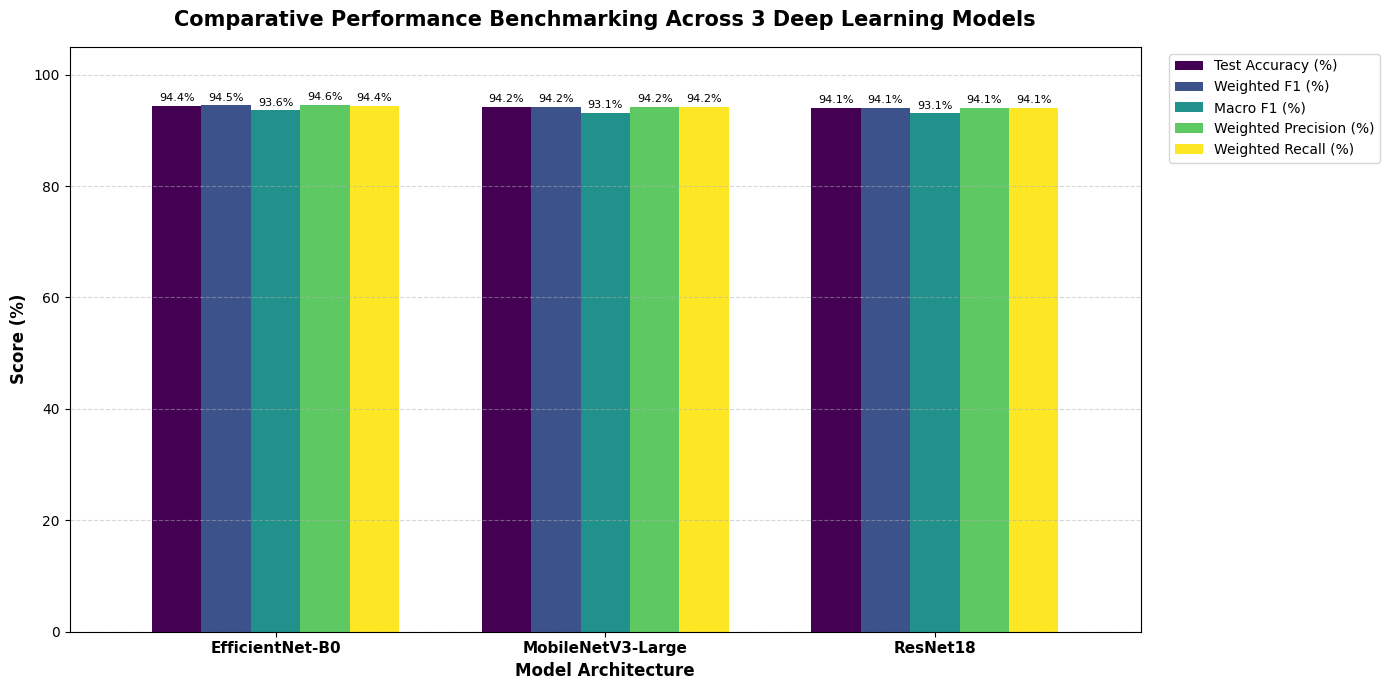

In [ ]:
# Create Leaderboard DataFrame
benchmark_data = []
for m_name in models_to_train:
    res = test_results[m_name]
    hist = histories[m_name]
    benchmark_data.append({
        'Model': m_name,
        'Test Accuracy (%)': res['accuracy'] * 100,
        'Weighted F1 (%)': res['weighted_f1'] * 100,
        'Macro F1 (%)': res['macro_f1'] * 100,
        'Weighted Precision (%)': res['weighted_precision'] * 100,
        'Weighted Recall (%)': res['weighted_recall'] * 100,
        'Training Time (min)': hist['training_time_sec'] / 60
    })

df_leaderboard = pd.DataFrame(benchmark_data).sort_values(by='Test Accuracy (%)', ascending=False).reset_index(drop=True)

print("\n==================================================")
print("          MODEL PERFORMANCE LEADERBOARD")
print("==================================================")
display(df_leaderboard)

# Comparative Bar Chart
metrics_to_plot = ['Test Accuracy (%)', 'Weighted F1 (%)', 'Macro F1 (%)', 'Weighted Precision (%)', 'Weighted Recall (%)']
df_plot = df_leaderboard.set_index('Model')[metrics_to_plot]

plt.figure(figsize=(14, 7))
ax = df_plot.plot(kind='bar', figsize=(14, 7), colormap='viridis', width=0.75)
plt.title("Comparative Performance Benchmarking Across 3 Deep Learning Models", fontsize=15, fontweight='bold', pad=15)
plt.ylabel("Score (%)", fontsize=12, fontweight='bold')
plt.xlabel("Model Architecture", fontsize=12, fontweight='bold')
plt.xticks(rotation=0, fontsize=11, fontweight='bold')
plt.ylim(0, 105)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add data labels
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f"{h:.1f}%", (p.get_x() + p.get_width() / 2., h),
                    ha='center', va='bottom', fontsize=8, xytext=(0, 2), textcoords='offset points')

plt.tight_layout()
plt.show()

## Step 9: Qualitative Test Predictions Visualization
Displays sample test images with True vs. Predicted labels for the top-performing model. Correct predictions are highlighted in **green**, while incorrect predictions are highlighted in **red**.

Visualizing test predictions for top model: 'EfficientNet-B0'


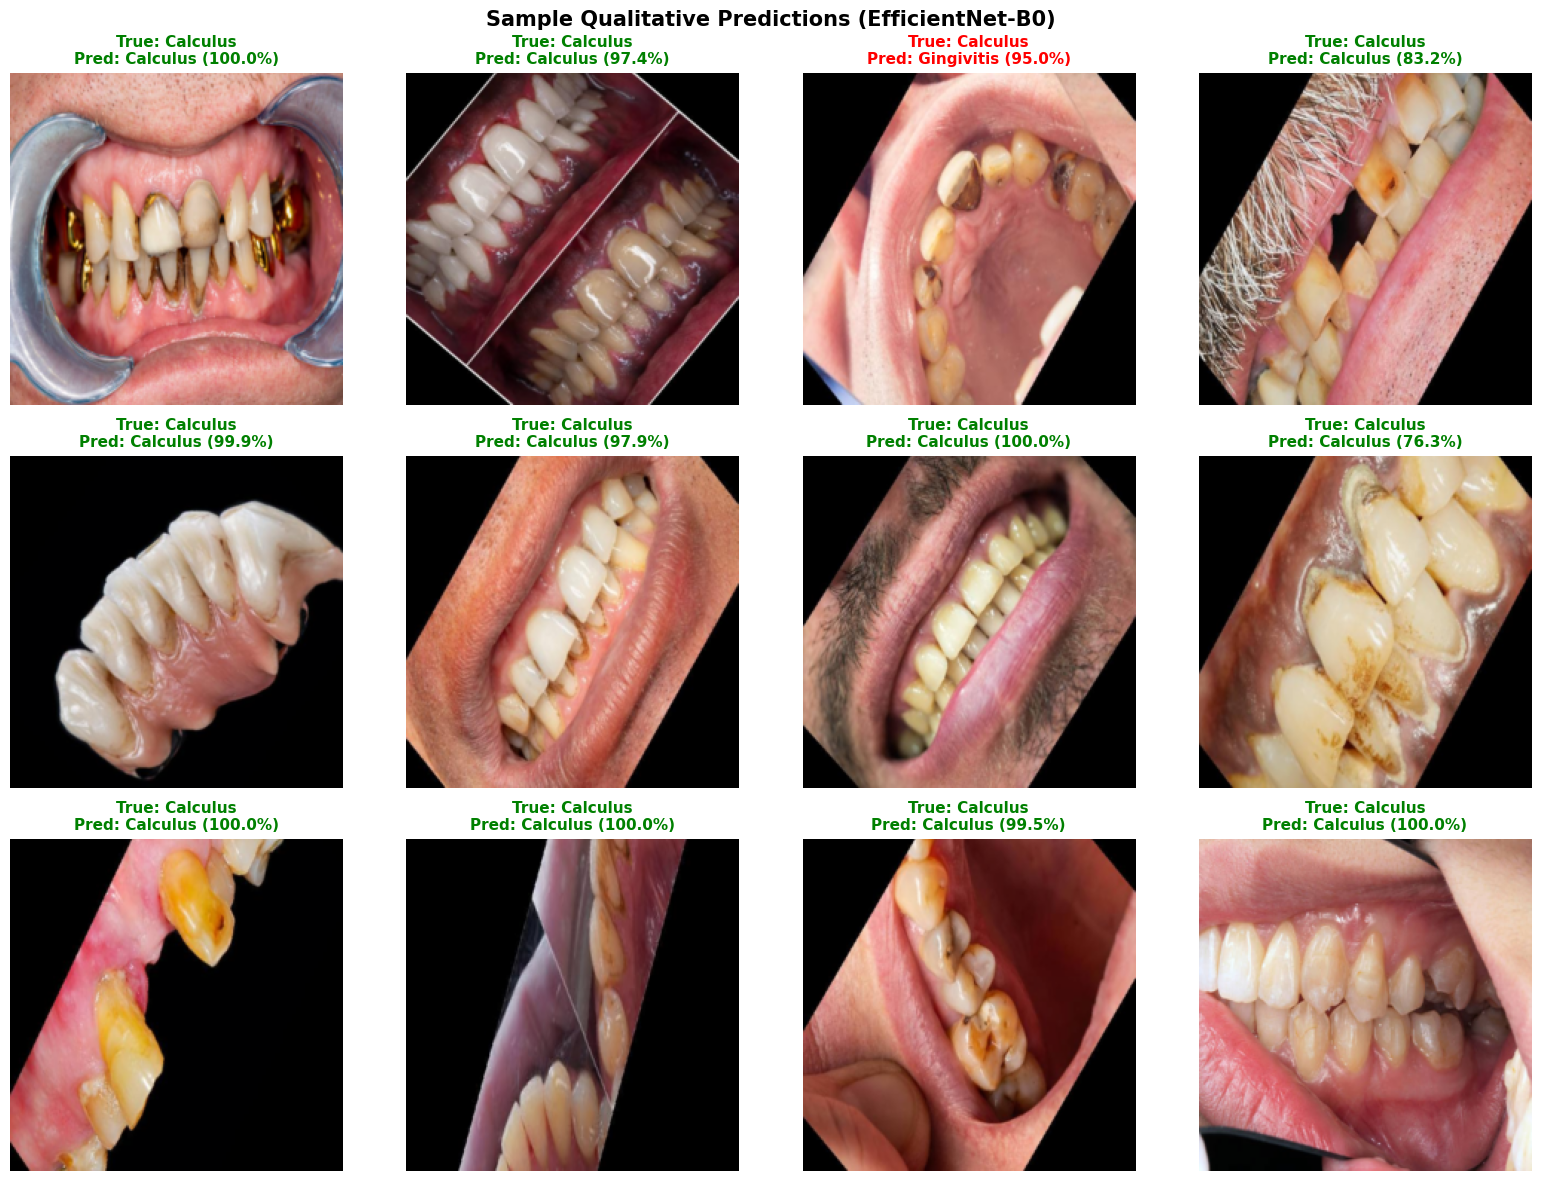

In [ ]:
# Identify best model
best_model_name = df_leaderboard.iloc[0]['Model']
best_model = trained_models[best_model_name]
print(f"Visualizing test predictions for top model: '{best_model_name}'")

def display_predicted_test_images(model, test_loader, class_names, num_samples=12):
    model.eval()
    plt.figure(figsize=(16, 12))
    images_shown = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs_dev = inputs.to(device)
            outputs = model(inputs_dev)
            probs = torch.softmax(outputs, dim=1)
            max_probs, preds = torch.max(probs, 1)

            for j in range(inputs.size(0)):
                if images_shown >= num_samples:
                    break

                img_tensor = inputs[j].numpy().transpose((1, 2, 0))
                # Unnormalize imagenet standard
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img_tensor = std * img_tensor + mean
                img_tensor = np.clip(img_tensor, 0, 1)

                true_cls = class_names[labels[j].item()]
                pred_cls = class_names[preds[j].item()]
                conf = max_probs[j].item() * 100

                color = 'green' if true_cls == pred_cls else 'red'

                images_shown += 1
                ax = plt.subplot(3, 4, images_shown)
                ax.imshow(img_tensor)
                ax.set_title(f"True: {true_cls}\nPred: {pred_cls} ({conf:.1f}%)",
                             fontsize=11, color=color, fontweight='bold')
                ax.axis('off')

            if images_shown >= num_samples:
                break

    plt.suptitle(f"Sample Qualitative Predictions ({best_model_name})", fontsize=15, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

display_predicted_test_images(best_model, test_loader, class_names, num_samples=12)

## Step 10: Explainable AI (Grad-CAM Visualizations)
Using `pytorch-grad-cam`, we generate class activation heatmaps to interpret the features (e.g. gum margins, enamel cavities, discoloration spots) driving model predictions.

In [ ]:
import os
import sys
import glob
import shutil
import random
import time
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Scikit-learn metrics & utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

# PyTorch & Torchvision
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision.models import (
    resnet18, ResNet18_Weights,
    efficientnet_b0, EfficientNet_B0_Weights,
    mobilenet_v3_large, MobileNet_V3_Large_Weights
)

# Install pytorch-grad-cam quietly if not available
try:
    import pytorch_grad_cam
except ImportError:
    !pip install grad-cam -q
    import pytorch_grad_cam

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

def visualize_grad_cam_for_best_model(model_name, model, test_loader, class_names, num_samples=6):
    model.eval()

    # Target layer selection based on architecture
    if 'ResNet' in model_name:
        target_layers = [model.layer4[-1]]
    elif 'EfficientNet' in model_name:
        target_layers = [model.features[-1]]
    elif 'MobileNet' in model_name:
        target_layers = [model.features[-1]]
    else:
        target_layers = [list(model.children())[-2]]

    cam = GradCAM(model=model, target_layers=target_layers)

    plt.figure(figsize=(15, 3 * num_samples))
    sample_count = 0

    for inputs, labels in test_loader: # Removed outer torch.no_grad() to allow for inner enable_grad
        for j in range(inputs.size(0)):
            if sample_count >= num_samples:
                break

            # Move input_tensor to device outside of no_grad for GradCAM processing later
            input_tensor = inputs[j].unsqueeze(0).to(device)
            true_cls = class_names[labels[j].item()]

            # Forward pass for prediction (still want no_grad for general inference)
            with torch.no_grad():
                outputs = model(input_tensor)
            pred_idx = torch.argmax(outputs, dim=1).item()
            pred_cls = class_names[pred_idx]

            # Grad-CAM calculation - re-enable gradients temporarily for this specific operation
            targets = [ClassifierOutputTarget(pred_idx)]
            with torch.enable_grad():
                # Create a clone of the input tensor that requires gradients for CAM calculation
                input_tensor_for_cam = inputs[j].unsqueeze(0).to(device).requires_grad_(True)
                grayscale_cam = cam(input_tensor=input_tensor_for_cam, targets=targets)[0]

            # Image processing for display
            img_np = inputs[j].numpy().transpose((1, 2, 0))
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            img_np = std * img_np + mean
            img_np = np.clip(img_np, 0, 1)

            visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

            sample_count += 1
            color = 'green' if true_cls == pred_cls else 'red'

            # Subplot Original Image
            ax1 = plt.subplot(num_samples, 2, 2 * sample_count - 1)
            ax1.imshow(img_np)
            ax1.set_title(f"Original - True: {true_cls}", fontsize=11, fontweight='bold')
            ax1.axis('off')

            # Subplot Grad-CAM Heatmap
            ax2 = plt.subplot(num_samples, 2, 2 * sample_count)
            ax2.imshow(visualization)
            ax2.set_title(f"Grad-CAM - Pred: {pred_cls}", fontsize=11, color=color, fontweight='bold')
            ax2.axis('off')

        if sample_count >= num_samples:
            break

    plt.suptitle(f"Grad-CAM Heatmap Interpretability ({model_name})", fontsize=15, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

visualize_grad_cam_for_best_model(best_model_name, best_model, test_loader, class_names, num_samples=6)

RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

<Figure size 1500x1800 with 0 Axes>

## Step 11: Exporting Best Model Checkpoint to Google Drive
Copies the trained best model checkpoint `.pth` file directly into your Google Drive `MyDrive` folder for easy download and deployment.

In [ ]:
best_model_file = f"{best_model_name.lower().replace('-', '_')}_dental.pth"

if in_colab:
    drive_export_dir = '/content/drive/MyDrive/dental_disease_models'
    os.makedirs(drive_export_dir, exist_ok=True)
    destination_file = os.path.join(drive_export_dir, best_model_file)
    shutil.copy(best_model_file, destination_file)
    print(f"Successfully copied best model '{best_model_file}' to Google Drive at: {destination_file}")
else:
    print(f"Best model checkpoint saved locally at: '{best_model_file}'")

print("\n==================================================")
print("   MASTER DENTAL CLASSIFICATION PIPELINE COMPLETE")
print("==================================================")

Successfully copied best model 'efficientnet_b0_dental.pth' to Google Drive at: /content/drive/MyDrive/dental_disease_models/efficientnet_b0_dental.pth

   MASTER DENTAL CLASSIFICATION PIPELINE COMPLETE
